<center><h1><b>ANALYSIS OF CUTS ON MC</b></h1></center>

In this notebook we want to search for the best cuts of the Monte Carlo data

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

# UPLOADING DATA

#### ALL OUR DATA

In [2]:
%%bash
ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

mc_pairs_001_010_pt1.pkl
mc_pairs_001_010_pt2.pkl
mc_pairs_001_010_pt3.pkl
mc_pairs_001_010_pt4.pkl
mc_pairs_001_010_pt5.pkl
mc_pairs_011_020_pt10.pkl
mc_pairs_011_020_pt11.pkl
mc_pairs_011_020_pt12.pkl
mc_pairs_011_020_pt13.pkl
mc_pairs_011_020_pt14.pkl
mc_pairs_011_020_pt15.pkl
mc_pairs_011_020_pt1.pkl
mc_pairs_011_020_pt2.pkl
mc_pairs_011_020_pt3.pkl
mc_pairs_011_020_pt4.pkl
mc_pairs_011_020_pt5.pkl
mc_pairs_011_020_pt6.pkl
mc_pairs_011_020_pt7.pkl
mc_pairs_011_020_pt8.pkl
mc_pairs_011_020_pt9.pkl
mc_pairs_021_030_pt10.pkl
mc_pairs_021_030_pt11.pkl
mc_pairs_021_030_pt12.pkl
mc_pairs_021_030_pt13.pkl
mc_pairs_021_030_pt14.pkl
mc_pairs_021_030_pt15.pkl
mc_pairs_021_030_pt16.pkl
mc_pairs_021_030_pt17.pkl
mc_pairs_021_030_pt18.pkl
mc_pairs_021_030_pt19.pkl
mc_pairs_021_030_pt1.pkl
mc_pairs_021_030_pt20.pkl
mc_pairs_021_030_pt2.pkl
mc_pairs_021_030_pt3.pkl
mc_pairs_021_030_pt4.pkl
mc_pairs_021_030_pt5.pkl
mc_pairs_021_030_pt6.pkl
mc_pairs_021_030_pt7.pkl
mc_pairs_021_030_pt8.pkl
mc_pairs

#### CHOSEN FILES

In [3]:
# list of all files to load
files = [
    "mc_pairs_001_010_pt1.pkl",
    "mc_pairs_001_010_pt2.pkl",
    "mc_pairs_001_010_pt3.pkl",
    "mc_pairs_011_020_pt1.pkl",
    "mc_pairs_011_020_pt2.pkl",
    "mc_pairs_011_020_pt3.pkl",
    "mc_pairs_011_020_pt4.pkl",
    "mc_pairs_011_020_pt5.pkl",
    "mc_pairs_011_020_pt6.pkl",
    "mc_pairs_021_030_pt1.pkl",
    "mc_pairs_021_030_pt2.pkl",
    "mc_pairs_021_030_pt3.pkl",
    "mc_pairs_021_030_pt4.pkl",
    "mc_pairs_021_030_pt5.pkl",
    "mc_pairs_031_040_pt1.pkl",
    "mc_pairs_031_040_pt2.pkl",
    "mc_pairs_031_040_pt3.pkl",
    # "mc_pairs_031_040_pt4.pkl",
    # "mc_pairs_031_040_pt5.pkl",
    # "mc_pairs_041_050_pt1.pkl",
    # "mc_pairs_041_050_pt2.pkl",
    # "mc_pairs_041_050_pt3.pkl",
    # "mc_pairs_041_050_pt4.pkl",
    # "mc_pairs_041_050_pt5.pkl",
]

#### UPLOAD DATA

In [4]:
# directory where the files are stored
folder = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))

# load each pickle into a DataFrame
final_results = []
for f in all_files:
    df = pd.read_pickle(f)
    final_results.append(df)
    del df
print(f"Loaded {len(final_results)} files.")
# concatenate all DataFrames into one
final_results = pd.concat(final_results, ignore_index=True)

Loaded 40 files.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 24_091_173 rows and 28 columns.
It occupies 5_146.43 MB


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_pt,neg_TPCka,neg_TOFka,neg_fDcaXY,...,track_pdg_pos,track_pdg_neg,mother_pdg_pos,mother_pdg_neg,beauty_pdg_pos,beauty_pdg_neg,mother_N_final_state_pos,mother_N_final_state_neg,mother_orig_ind_pos,mother_orig_ind_neg
0,-1.306505e-03,1.647857,1.449501,1.590537,2.064567,0.378364,0.443343,-6.947757,133.719315,-0.093189,...,211.0,-211.0,421.0,0.0,0.0,0.0,2.0,0.0,9618.0,-1.0
1,-7.080836e-03,0.947897,0.935076,0.698830,5.386100,-0.238735,0.443343,-6.947757,133.719315,-0.093189,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
2,5.584245e-03,0.813485,0.819674,0.772823,3.091237,0.265503,0.443343,-6.947757,133.719315,-0.093189,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
3,-1.640872e-02,0.966982,0.953821,0.597828,3.955609,-0.544734,0.443343,-6.947757,133.719315,-0.093189,...,2212.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
4,1.596988e-02,1.400717,1.328300,0.452560,3.330226,0.408916,0.443343,-6.947757,133.719315,-0.093189,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
24091168,-1.530073e-06,0.819055,0.656771,1.502924,0.338599,-0.999868,0.540042,-4.852590,-999.000000,-0.000203,...,321.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
24091169,-2.625796e-06,1.295818,1.304763,0.748611,0.015535,-0.600804,0.540042,-4.852590,-999.000000,-0.000203,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
24091170,-2.382644e-07,0.765154,0.748439,1.087152,0.005929,0.929990,0.540042,-4.852590,-999.000000,-0.000203,...,211.0,-211.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0
24091171,-5.956648e-07,1.904229,1.759084,1.690007,0.002692,0.360649,0.591184,-1.434192,-25.269445,-0.000243,...,211.0,-211.0,421.0,0.0,0.0,0.0,2.0,0.0,1307433.0,-1.0
24091172,8.985191e-06,2.717647,2.650951,1.853758,0.006853,0.604630,0.774583,-0.094373,-999.000000,0.003663,...,211.0,-211.0,421.0,0.0,0.0,0.0,2.0,0.0,1307433.0,-1.0


## TRUE $D_0$ IN OUR DATA

In [6]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = (
    (final_results["track_pdg_pos"] == 211 ) &
    (final_results["track_pdg_neg"] == -321 ) &
    (final_results["mother_pdg_pos"] == 421) &
    (final_results["mother_pdg_neg"] == 421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)
mask_true_anti_d0 = (
    (final_results["track_pdg_pos"] == 321) &
    (final_results["track_pdg_neg"] == -211) &
    (final_results["mother_pdg_pos"] == -421) &
    (final_results["mother_pdg_neg"] == -421) &
    (final_results["beauty_pdg_pos"] == 0) &
    (final_results["beauty_pdg_neg"] == 0) &
    (final_results["mother_N_final_state_pos"] == 2) &
    (final_results["mother_N_final_state_neg"] == 2)
)

In [8]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print("Remaining pairs:   ", len(final_results)-d0_tot-anti_d0_tot )
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       6125
Number of anti-D0:  6538
Remaining pairs:    24078510
Fraction of D0 and anti-D0 over total: 0.0526%


The variables we have to work with are:

In [9]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_pt', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY',
       'pos_pt', 'pos_TPCpi', 'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi',
       'neg_TOFpi', 'pos_TPCka', 'pos_TOFka', 'track_pdg_pos', 'track_pdg_neg',
       'mother_pdg_pos', 'mother_pdg_neg', 'beauty_pdg_pos', 'beauty_pdg_neg',
       'mother_N_final_state_pos', 'mother_N_final_state_neg',
       'mother_orig_ind_pos', 'mother_orig_ind_neg'],
      dtype='object')


Example: the variable 'neg_TOFka' refers to the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D_0$ case, a $\pi^-$ for the $anti-D_0$ case, and something else in background case.

---

---

# INVARIANT MASS
We now plot the data, remembering to plot both the columns for mass and anti-mass because we want to include the reflex component.

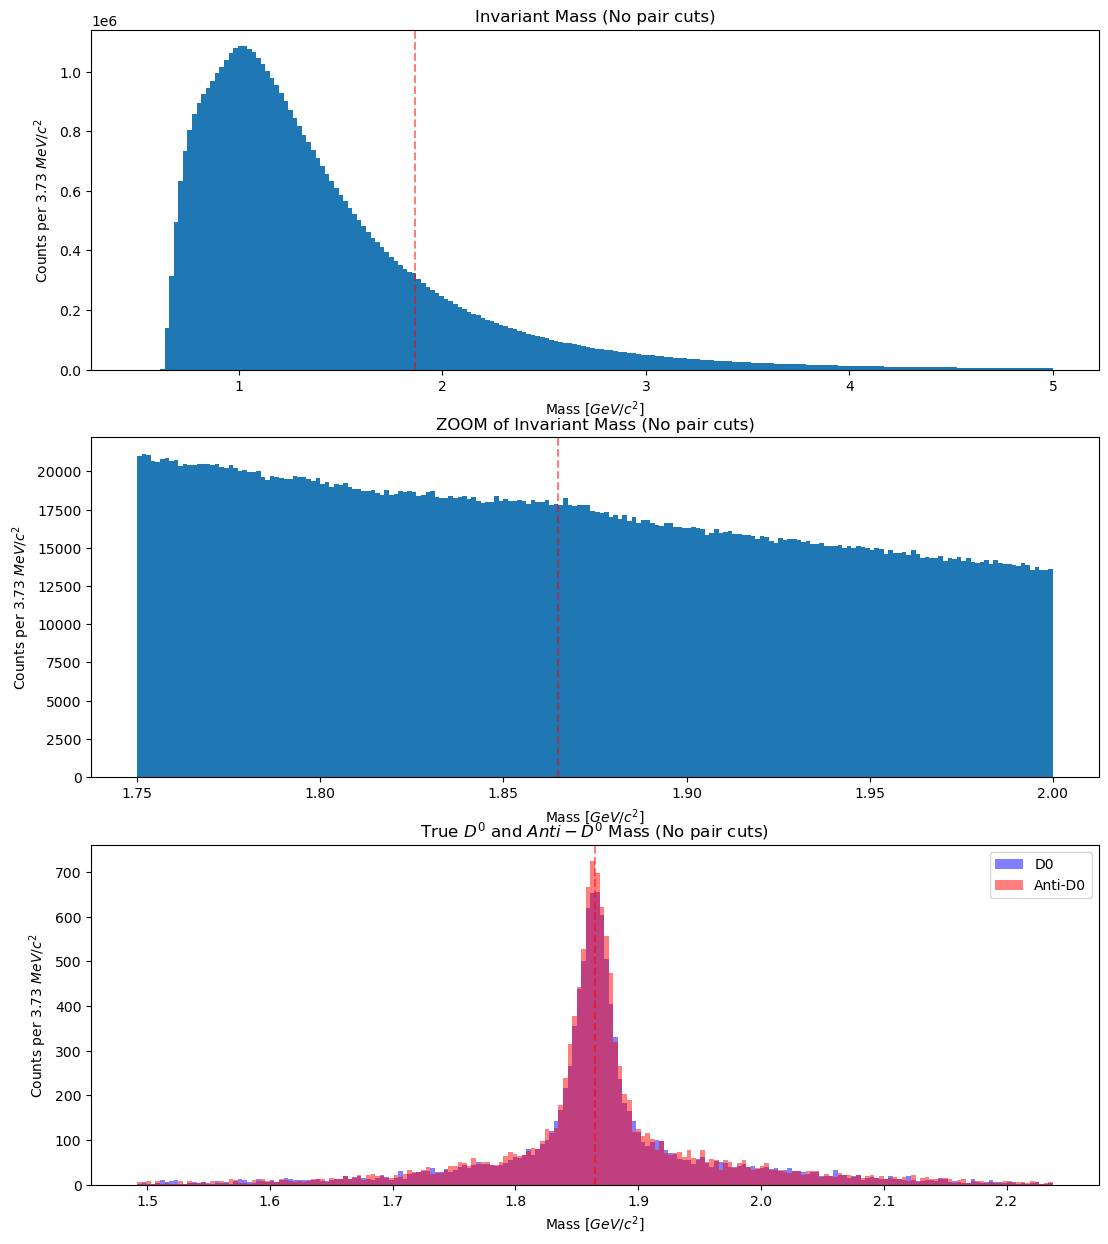

In [10]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 200

num_of_plots = 3
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,5*num_of_plots)  )

# GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values])
axs[0].hist( data, bins=N_BINS, range=(0.5, 5))
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No pair cuts)")
#axs[0].set_xticks( np.arange(0, 8) )

# ZOOM OF GLOBAL PLOT
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values] )
axs[1].hist( data, bins=N_BINS, range=(1.75, 2))
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("ZOOM of Invariant Mass (No pair cuts)")
#axs[1].set_xticks( np.arange(0, 8) )

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO
data = np.concatenate([ final_results.loc[mask_true_d0, "inv_mass"].values, final_results.loc[mask_true_d0, "anti_mass"].values ])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = np.concatenate([final_results.loc[mask_true_anti_d0, "inv_mass"].values, final_results.loc[mask_true_anti_d0, "anti_mass"].values])
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title("True $D^0$ and $Anti-D^0$ Mass (No pair cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

del data
#plt.savefig("D0_Mass_MC.png")
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.  

Also the distribution of $D_0$ and $anti-D_0$ is almost the same.

---

---

# VARIABLES DISTRIBUTION
Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $\pi^+$ TRACKS
Let's observe the distribution of the variables for the $\pi^+$ tracks, for both the known $D_0$ and also for all the combinatory background.

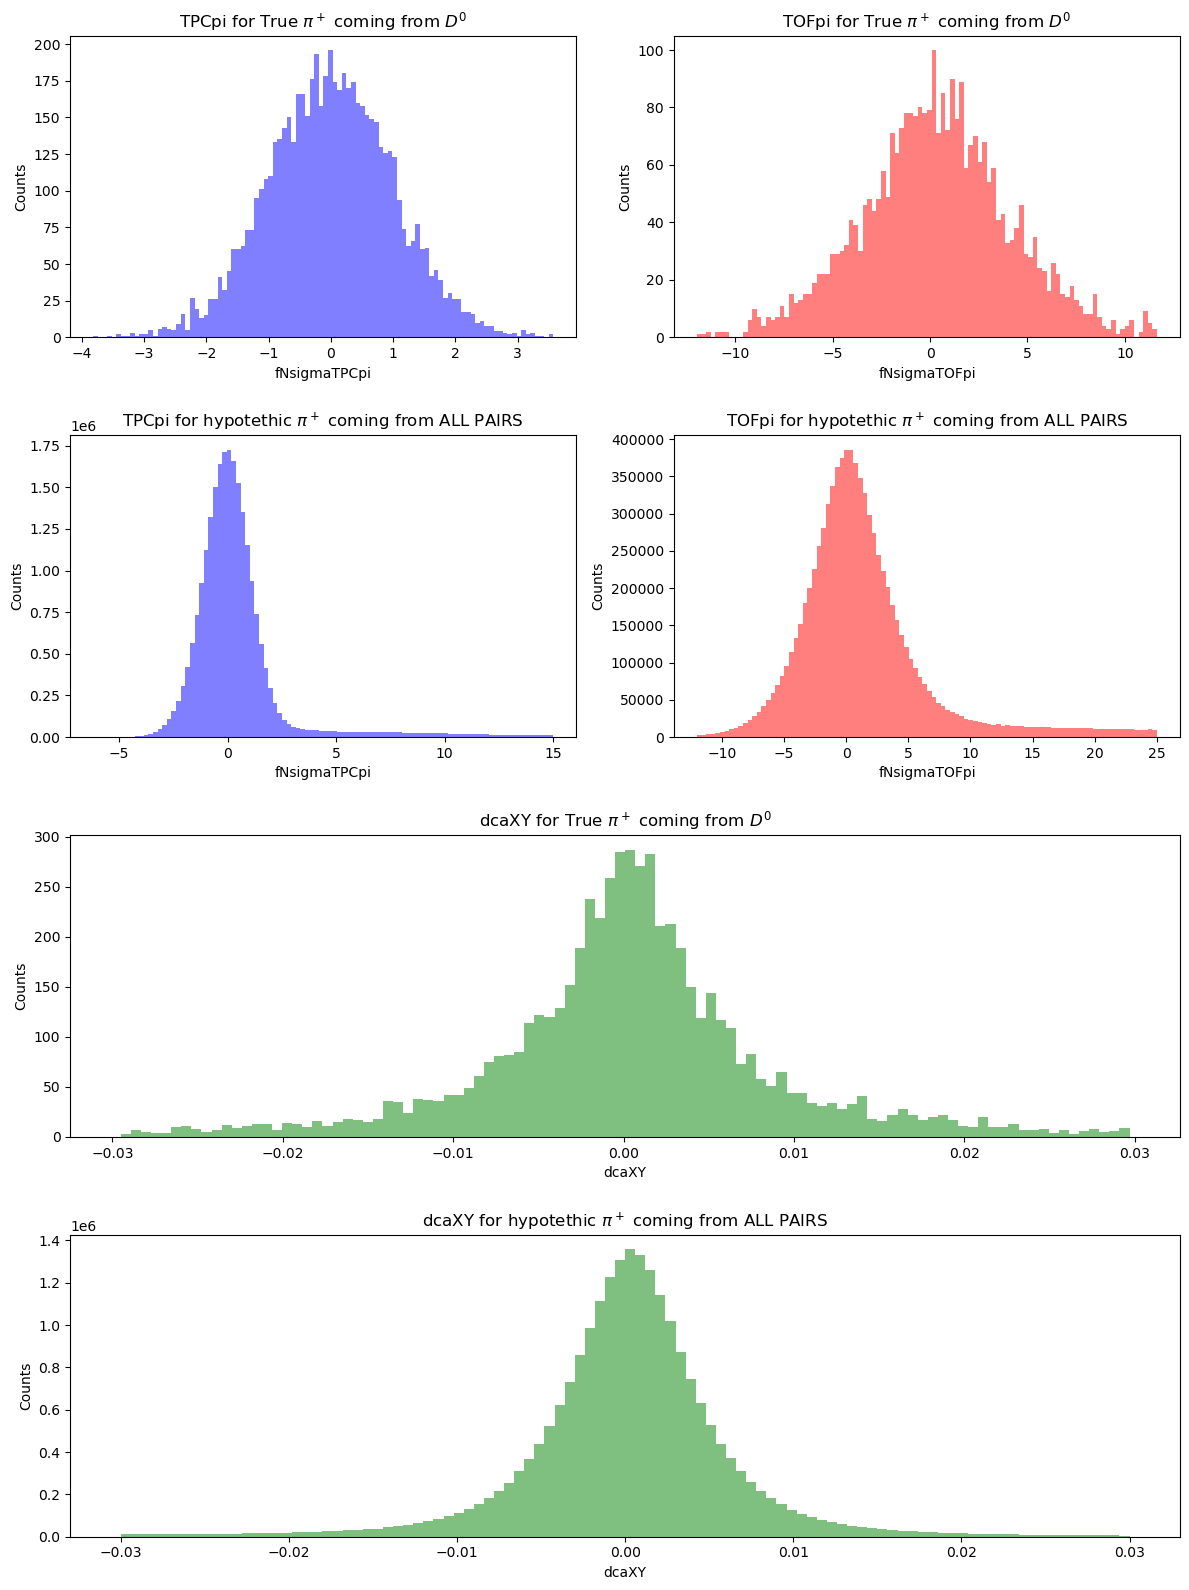

In [11]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 16)
)

# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for True $\pi^+$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for True $\pi^+$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['pos_TPCpi'].values
data = data[(data > -7) & (data < 15)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^+$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -12) & (data < 25)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^+$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for True $\pi^+$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


Sadly, they are all too similar.

### $\pi^-$ TRACKS
Let's observe the distribution of the variables for the $\pi^-$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

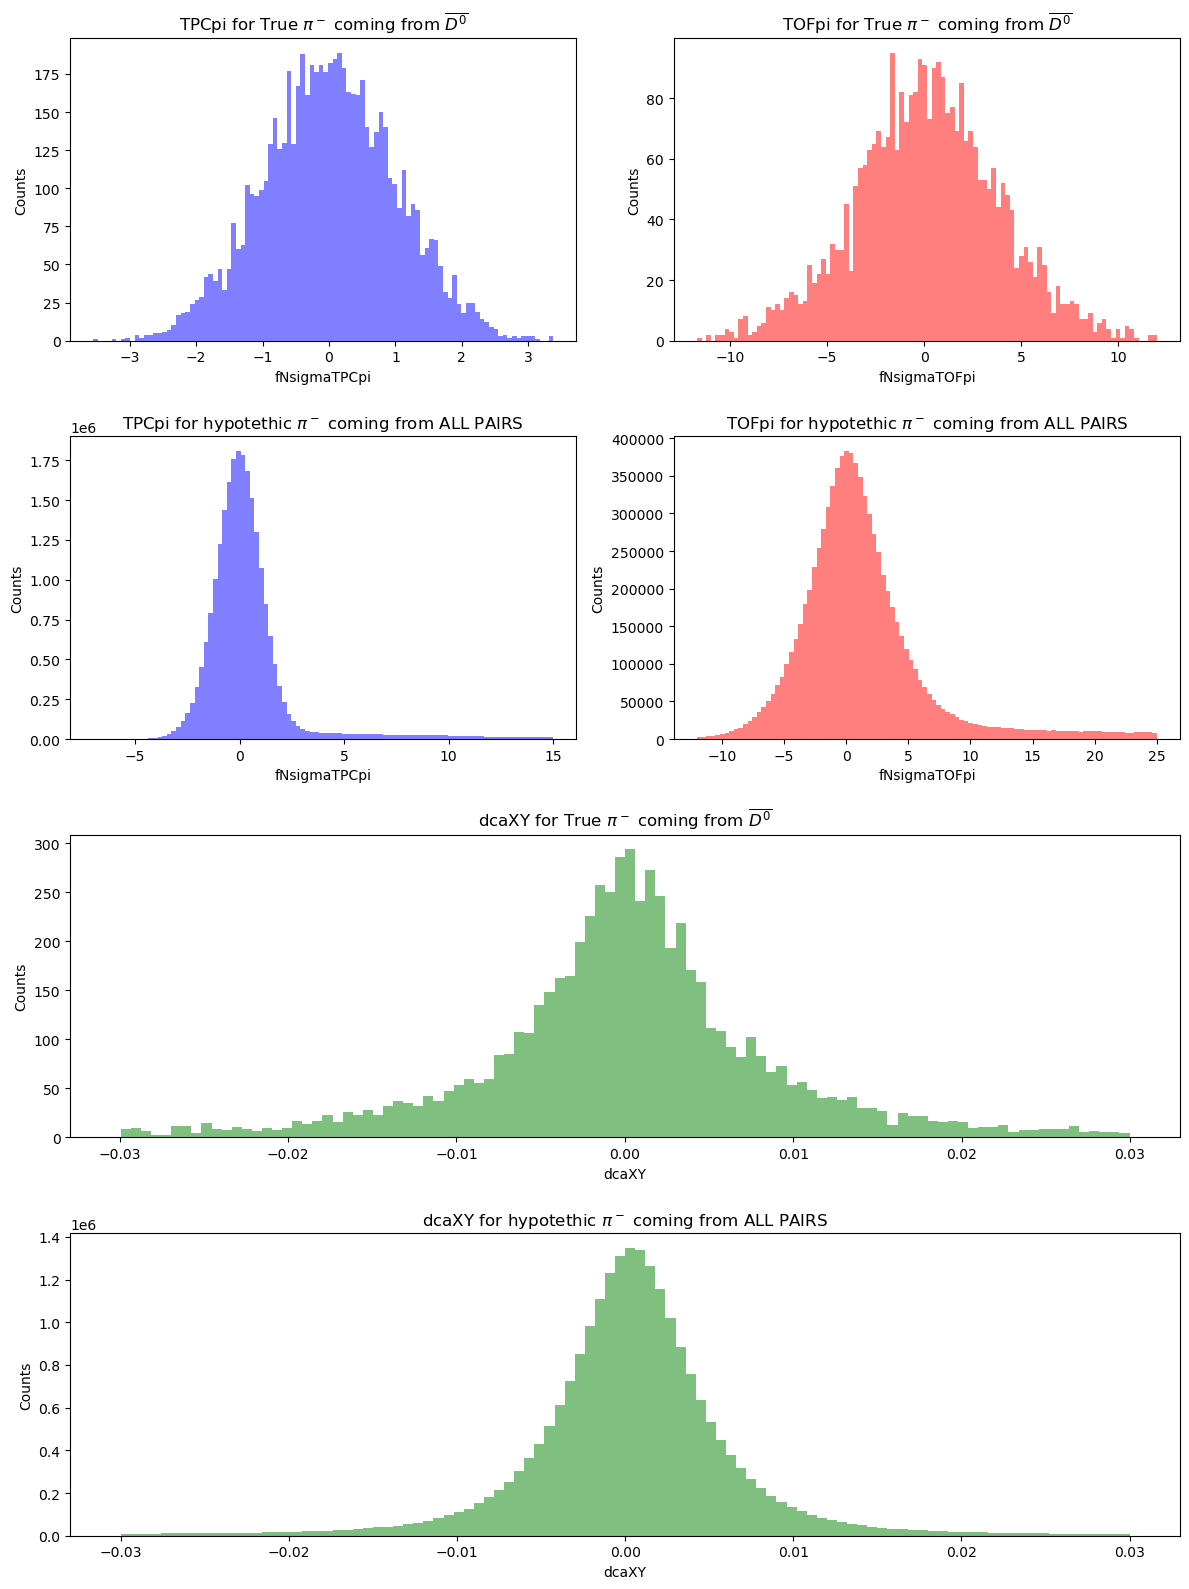

In [12]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_anti_D0", "tofpi_anti_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 16)
)

# --- Plot TPCpi for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['neg_TPCpi'].values
data = data[(data > -7) & (data < 15)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^-$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['neg_TOFpi'].values
data = data[(data > -12) & (data < 25)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^-$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot dcaXY for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for True $\pi^-$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $K^-$ TRACKS
Let's observe the distribution of the variables for the $Kaons^-$ tracks, for both the known $D_0$ and also for all the combinatory background.

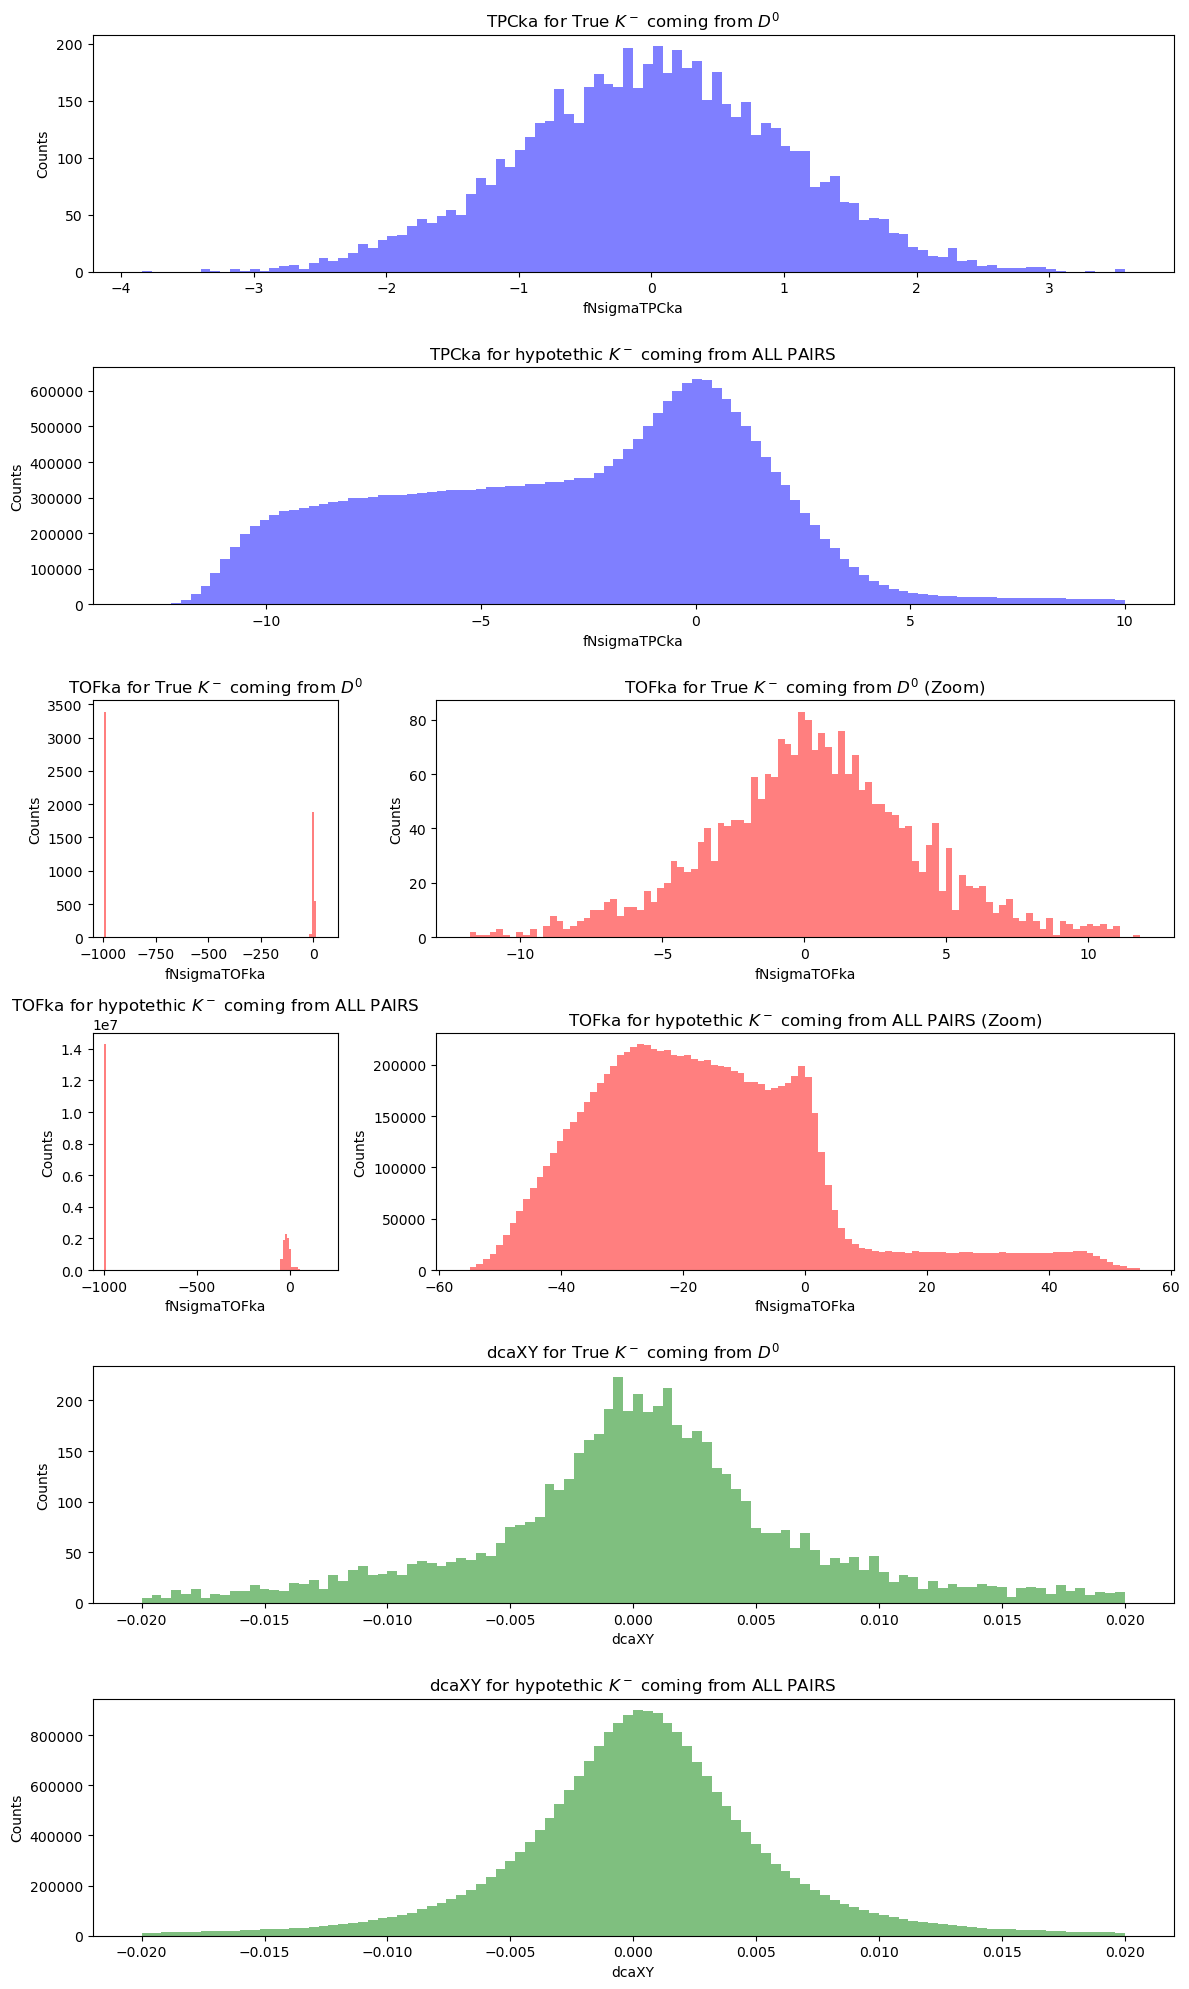

In [13]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_d0, 'neg_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for True $K^-$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['neg_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^-$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for True $K^-$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_D0"].set_title(r"TOFka for True $K^-$ coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^-$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^-$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for True $K^-$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

We can see that the variables TPCka and TOFka can be very useful as cuts. 

But what to do with data at -999 TOF? Let's see.

In [15]:
print(f"Total number of D0s: {d0_tot}")
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0s with TOFka = -999:  {len(data)/d0_tot:.2f}")
print(f"Fraction of True D0s with TOFka != -999: { (d0_tot-len(data)) / d0_tot :.2f} \n")

print(f"Total number of data: {len(final_results)}")
data = final_results['neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all data with TOFka = -999:  {len(data)/len(final_results) :.2f}")
print(f"Fraction of all data with TOFka != -999: { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0s: 6125
Fraction of True D0s with TOFka = -999:  0.55
Fraction of True D0s with TOFka != -999: 0.45 

Total number of data: 24091173
Fraction of all data with TOFka = -999:  0.59
Fraction of all data with TOFka != -999: 0.41


If we keep the data with TOFka=-999, we keep a lot of background.  
Instead if we remove it, yeah we lose 44% of true D0, but we stay in a zone where our cut is effective (see red plot above). So cutting away TOFka=-999 could be a good choice.

### $K^+$ TRACKS
Let's observe the distribution of the variables for the $Kaons^+$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

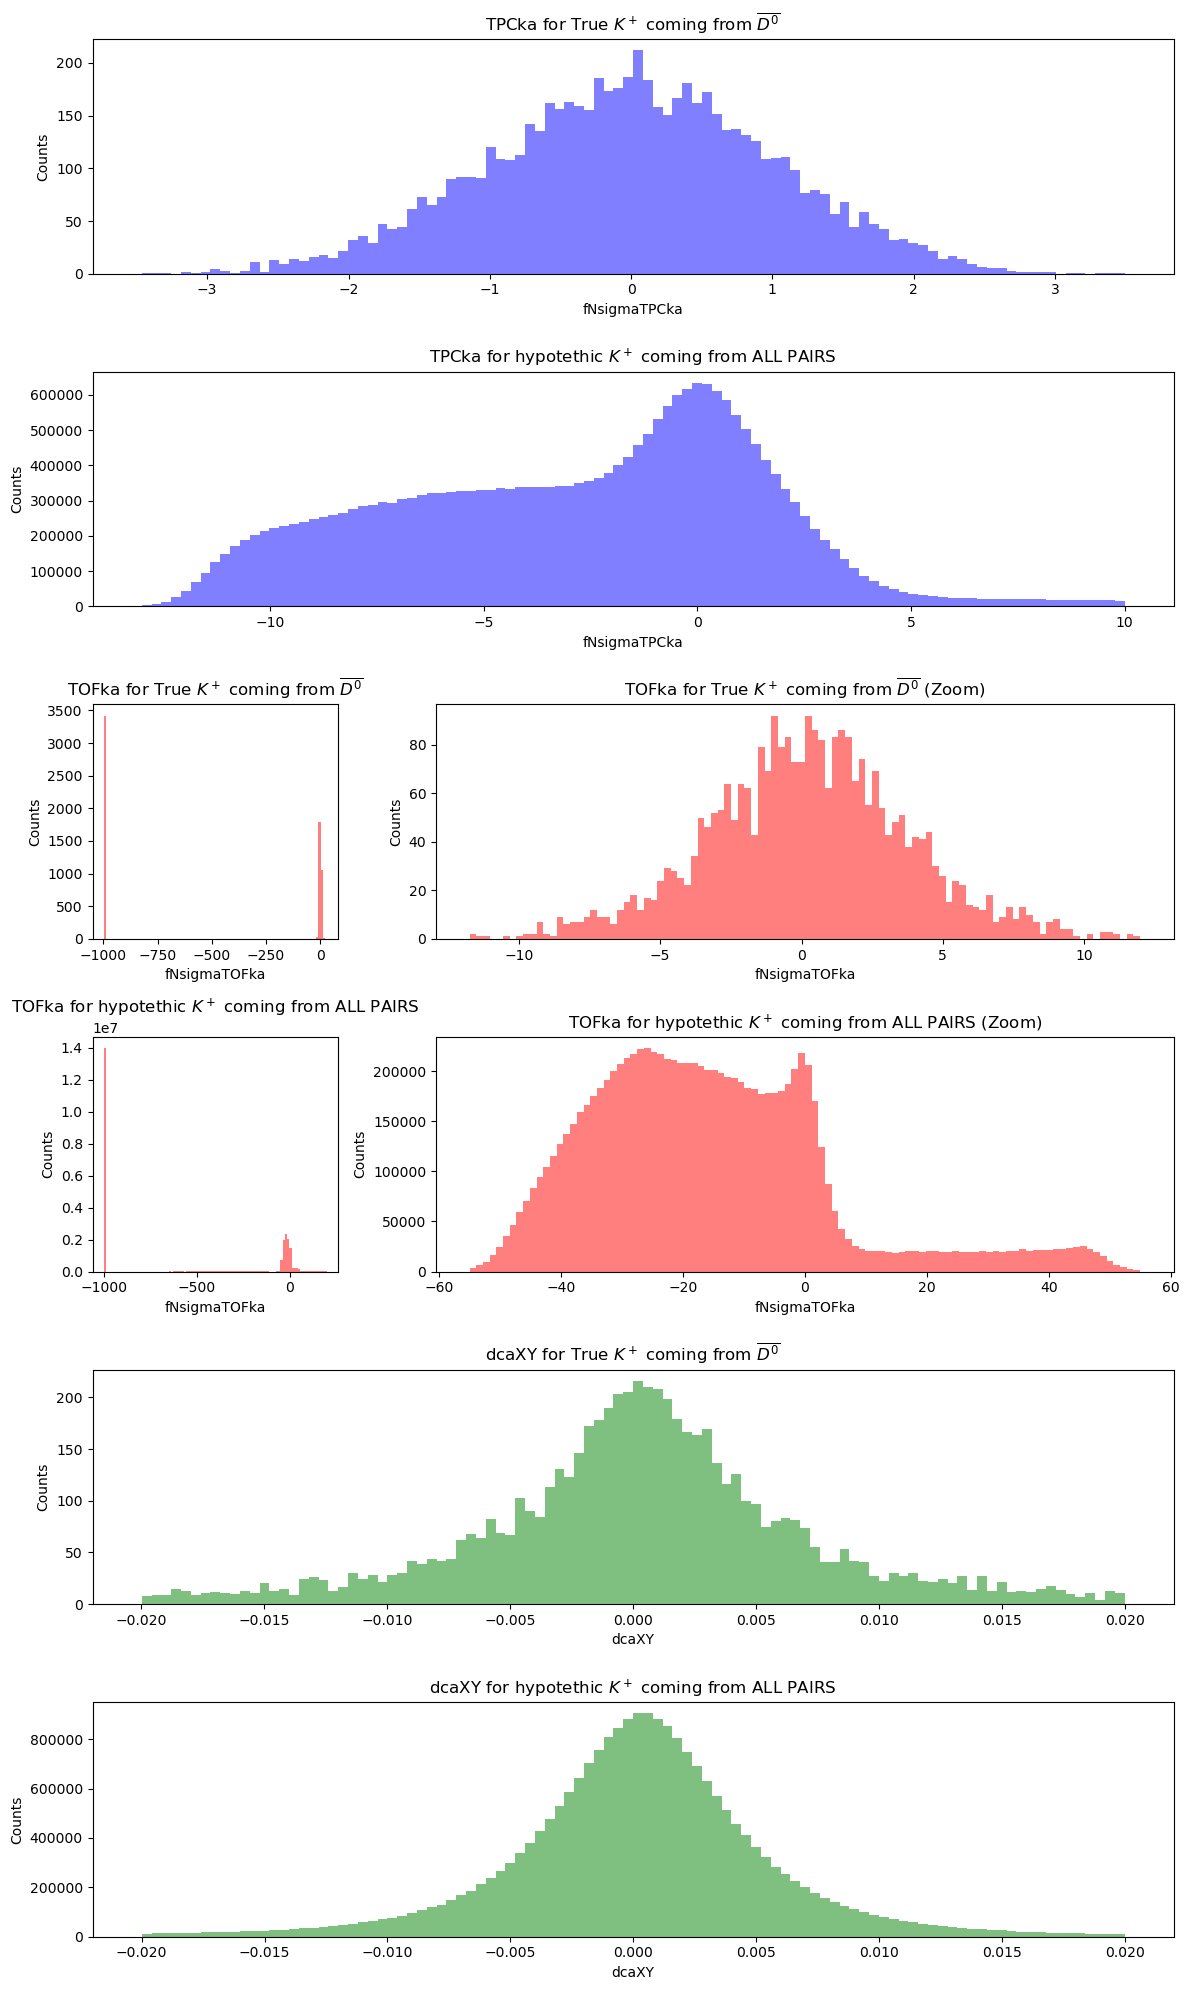

In [16]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_anti_D0", "tpcka_anti_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_anti_D0", "tofka_zoom_anti_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE anti_D0---
data = final_results.loc[mask_true_anti_d0, 'pos_TPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for True $K^+$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['pos_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^+$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for True $K^+$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_anti_D0"].set_title(r"TOFka for True $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofka_zoom_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['pos_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^+$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^+$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

# --- Plot dcaXY FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for True $K^+$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

### POYNTING ANGLE

With the cut at 0.95 we keep 44.36% of original $D^0$s
With the cut at 0.95 we keep 45.40% of original $\overline{D^0}$s


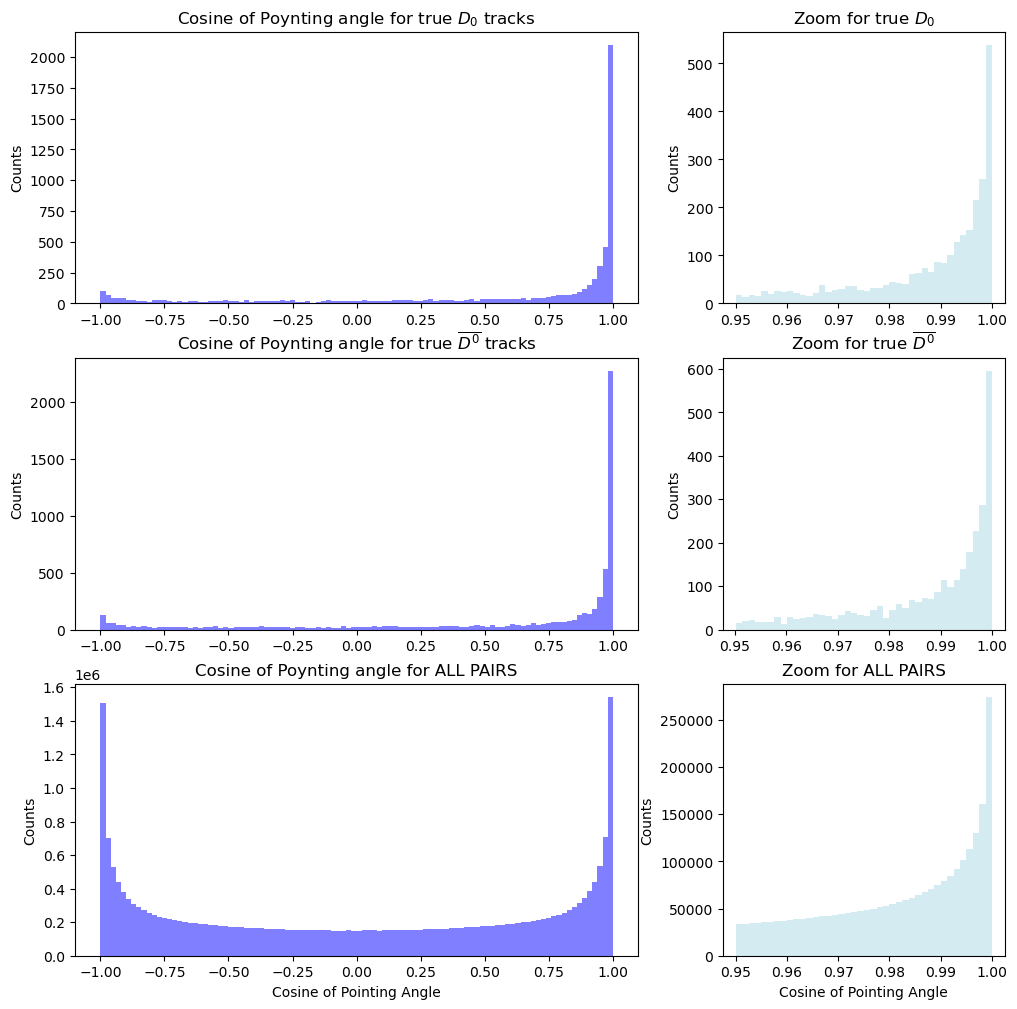

In [17]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [2, 1]}
)

# --- Plot cosine of poynting angle FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'cos_pointing'].values
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("Cosine of Poynting angle for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_D0"].hist( data, bins=40, color="lightblue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original $D^0$s")

# --- Plot cosine of poynting angle FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'cos_pointing'].values
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"Cosine of Poynting angle for true $\overline{D^0}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_anti_D0"].hist( data, bins=40, color="lightblue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title("Zoom for true $\overline{D^0}$")

print(f"With the cut at {cut} we keep {len(data)/anti_d0_tot*100:.2f}% of original $\overline{{D^0}}$s")

# --- Plot cosine of poynting angle FOR ALL PAIRS ---
data = final_results['cos_pointing'].values
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("Cosine of Pointing Angle")
axes["total_all"].set_title("Cosine of Poynting angle for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_all"].hist( data, bins=40, color="lightblue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
axes["zoom_all"].set_title("Zoom for ALL PAIRS")

plt.show()

del data

Sadly, the two distributions are verys similar.

#### dcaXY PRODUCT

With the cut at 2e-05 we keep 59.10% of original D0s
With the cut at 2e-05 we keep 56.64% of original anti-D0s


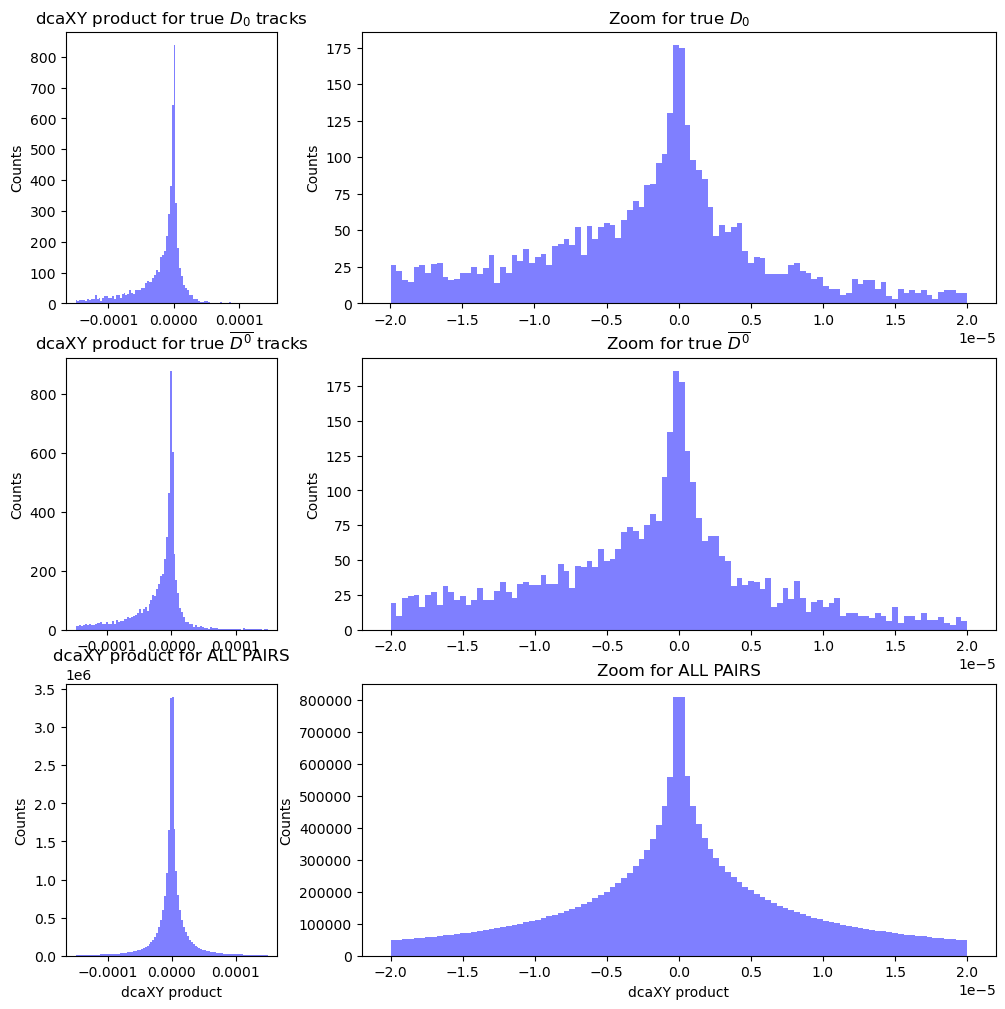

In [23]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot dcaXY product FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("dcaXY product for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D0s")

# --- Plot dcaXY product FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"dcaXY product for true $\overline{D^0}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title(r"Zoom for true $\overline{D^0}$")

print(f"With the cut at {cut} we keep {len(data)/anti_d0_tot*100:.2f}% of original anti-D0s")

# --- Plot dcaXY product FOR ALL PAIRS ---
data = final_results['dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("dcaXY product")
axes["total_all"].set_title("dcaXY product for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("dcaXY product")
axes["zoom_all"].set_title("Zoom for ALL PAIRS")

plt.show()
del data

#### $p_T$ DISTRIBUTION

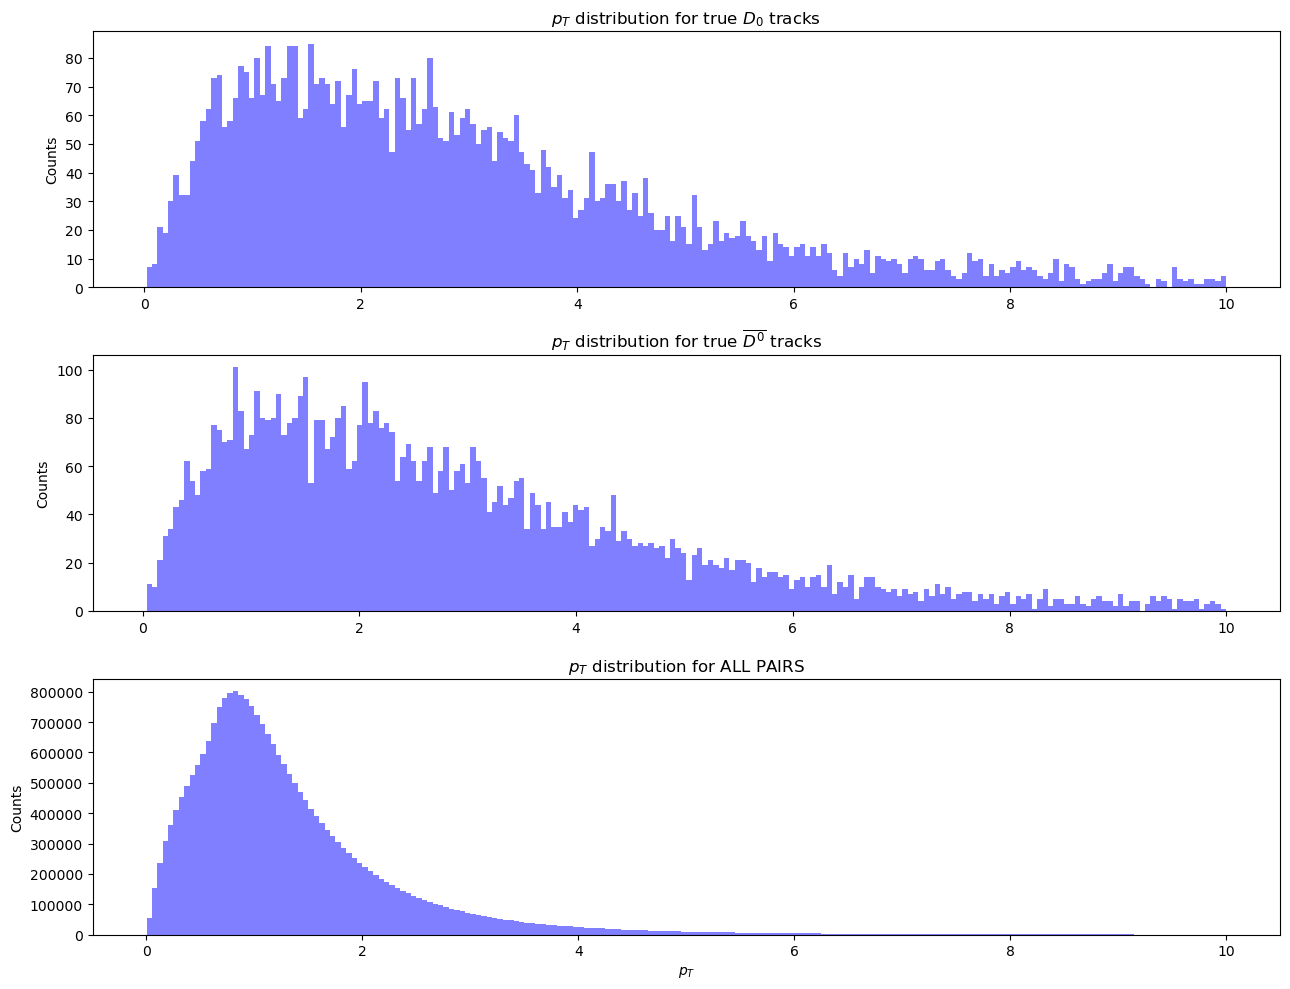

In [19]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$ or $[3-6]$ could be useful to find the signal.

#### DECAY LENGTH

With the cut at 0.05 we keep 83.54% of original D0s
With the cut at 0.05 we keep 83.65% of original anti-D0s


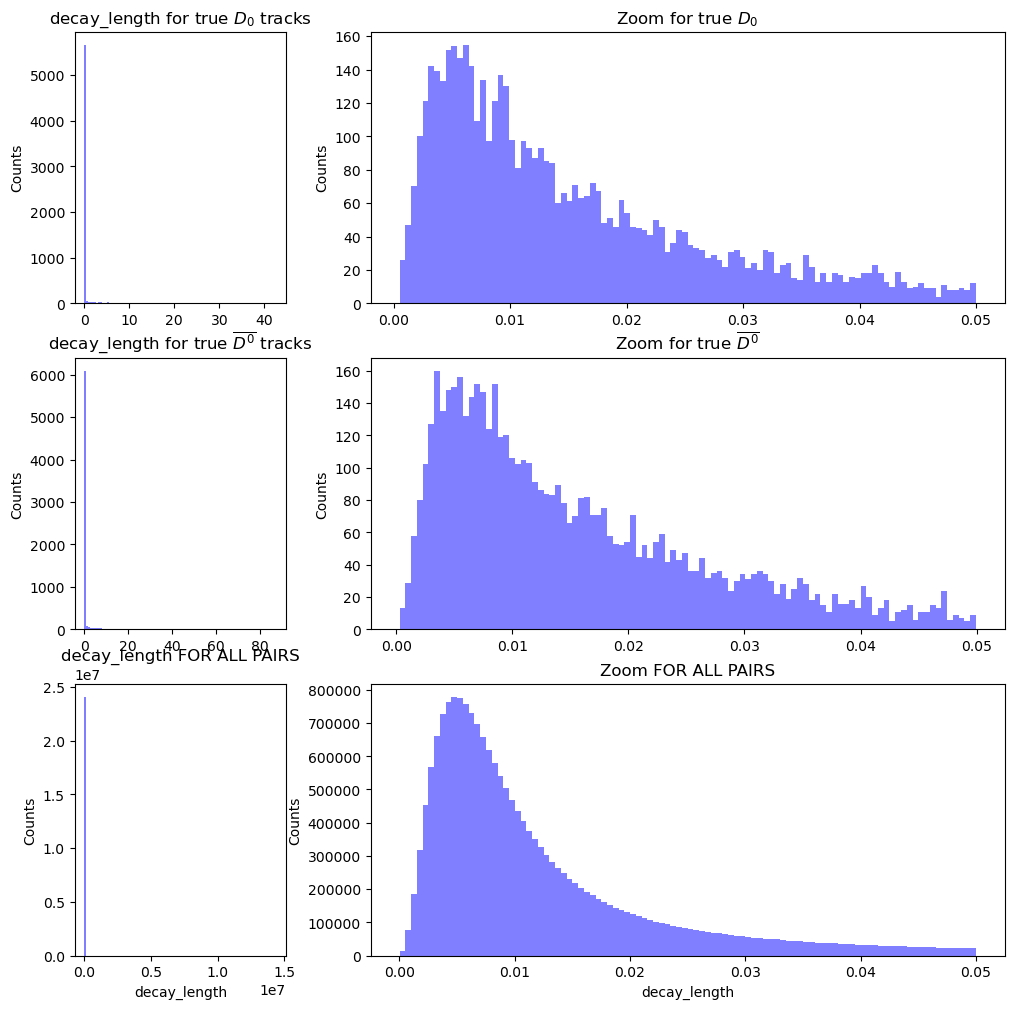

In [24]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot decay length FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("decay_length for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we keep {len(data)/d0_tot*100:.2f}% of original D0s")

# --- Plot decay length FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"decay_length for true $\overline{{D^0}}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title(r"Zoom for true $\overline{{D^0}}$")

print(f"With the cut at {cut} we keep {len(data)/anti_d0_tot*100:.2f}% of original anti-D0s")

# --- Plot decay length FOR ALL PAIRS ---
data = final_results['decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("decay_length")
axes["total_all"].set_title("decay_length FOR ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("decay_length")
axes["zoom_all"].set_title("Zoom FOR ALL PAIRS")

plt.show()
del data

---

---

---

# TRYING CUTS

### CHOSEN CUTS

In [26]:
# we create the cuts as a mask:
cuts = (
    (final_results['neg_TOFka'] > -5) & (final_results['neg_TOFka'] < 5) & 
    (final_results['neg_TPCka'] > -2) & (final_results['neg_TPCka'] < 2) &
    (final_results['pt'] > 2) & (final_results['pt'] < 4) &
    (final_results['cos_pointing'] > 0.95)
)

### INVARIANT MASS PLOT

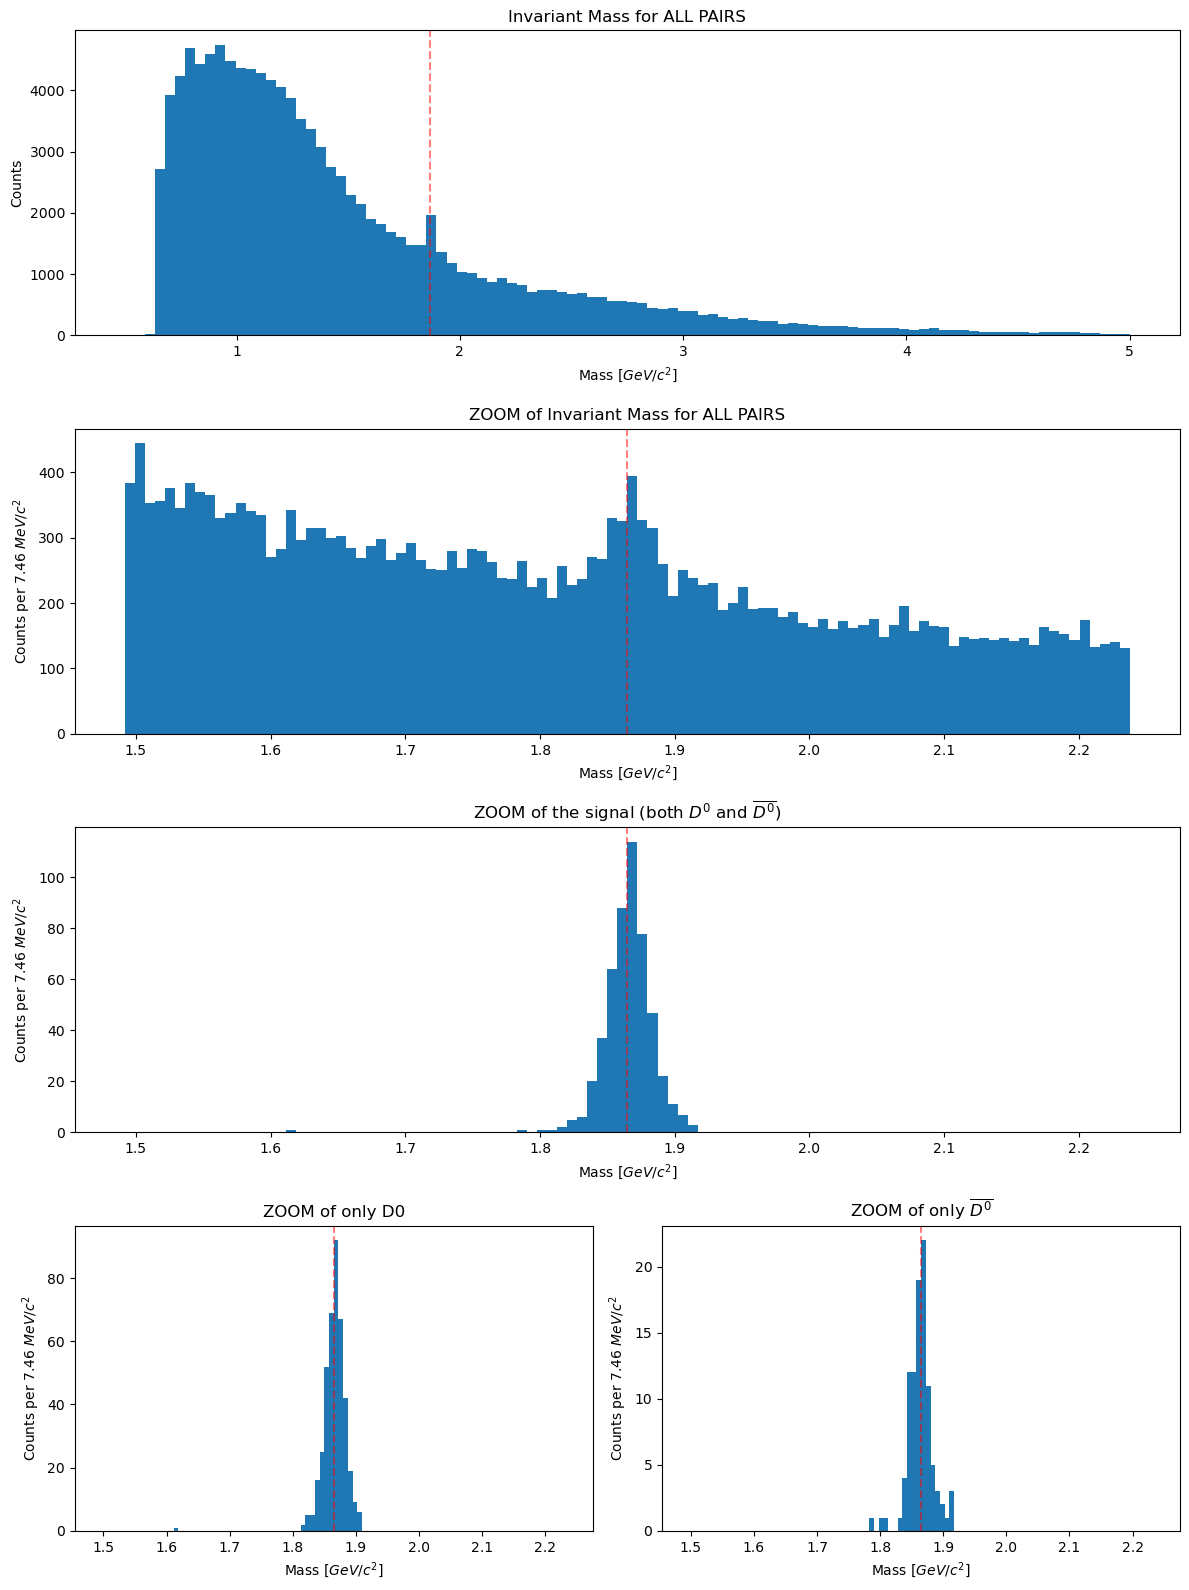

In [29]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0     # for zoom
N_BINS = 100

# Layout con due colonne
zones = [
    ["total", "total"],
    ["total_zoom", "total_zoom"],
    ["signal", "signal"],           # both D0 and anti_D0
    ["D0", "anti_D0"]
]

# Creazione della figura usando subplot_mosaic
fig, axs = plt.subplot_mosaic(
    zones,
    figsize=(12, 16),
    gridspec_kw={"width_ratios": [1, 1]}
)

# our cutted data with reflex component:---------------------------------
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate( [data_inv_mass, data_anti_mass] )

# PLOT OF ALL PAIRS
axs["total"].hist( data, bins=N_BINS, range=(0.5, 5))
axs["total"].axvline(x=m_d0, color="red", ls='--', alpha= 0.5)
axs["total"].set_xlabel("Mass [$GeV/c^2$]")
axs["total"].set_ylabel(f"Counts")
axs["total"].set_title("Invariant Mass for ALL PAIRS")

# ZOOM OF ALL PAIRS
axs["total_zoom"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
axs["total_zoom"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total_zoom"].set_title("ZOOM of Invariant Mass for ALL PAIRS")

# out cutted and true D0 -------------------------------------------------
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )

# ZOOM OF the signal:
axs["signal"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["signal"].set_title("ZOOM of the signal (both $D^0$ and $\overline{{D^0}}$)")

# ZOOM OF only D0
axs["D0"].hist( data_inv_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["D0"].set_title("ZOOM of only D0")

# ZOOM OF only anti_D0
axs["anti_D0"].hist( data_anti_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["anti_D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["anti_D0"].set_title("ZOOM of only $\overline{{D^0}}$")

#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

In [32]:
print(f"Total D0 before cuts:             {d0_tot}")
print(f"Total D0 found after cuts:        {len(data_inv_mass_true)} \n")
print(f"Total anti-D0 before cuts:        {anti_d0_tot}")
print(f"Total anti-D0 found after cuts:   {len(data_anti_mass_true)}")

Total D0 before cuts:             6125
Total D0 found after cuts:        413 

Total anti-D0 before cuts:        6538
Total anti-D0 found after cuts:   99


---

# FITTING MASS

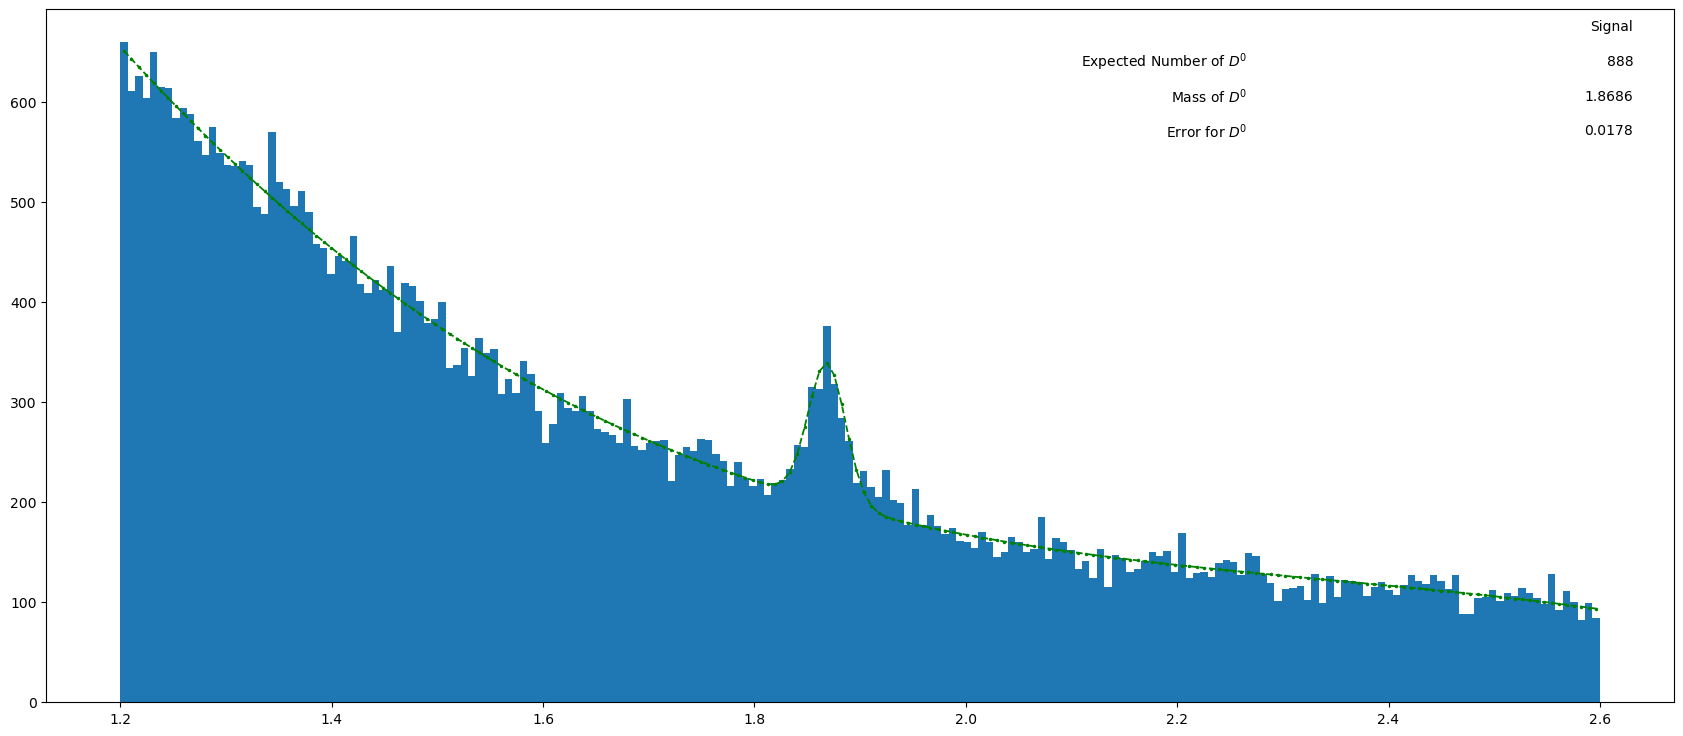

In [42]:
def both(x, N1, mu1, sigma1, N2, mu2, sigma2, a, b):
    return ( N1*norm.pdf(x, loc=mu1, scale=sigma1) + N2*norm.pdf(x, loc=mu2, scale=sigma2) + a*x +b  )

MIN_MASS, MAX_MASS = 1.2, 2.6
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS

signal_params = [50, m_d0, 0.05]
mirror_params = [1.132*50, m_d0, 0.1]
back_params = [133, 1000]

fig, ax = plt.subplots(figsize=(21,9))
both_counts, both_edges, _  = ax.hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = ( both_edges[:-1] + both_edges[1:] ) / 2.
both_fit_res = curve_fit( f = both, xdata=both_centers, ydata=both_counts, 
                            sigma = np.clip(np.sqrt(both_centers),a_min=1, a_max=1e+09),
                            p0 = [signal_params[0], signal_params[1], signal_params[2],
                                  mirror_params[0], mirror_params[1], mirror_params[2],
                                  back_params[0], back_params[1]    ]  )
both_params = both_fit_res[0]
ax.plot( both_centers, both( both_centers, both_params[0], both_params[1], both_params[2], both_params[3], both_params[4], \
                                           both_params[5],  both_params[6],  both_params[7]),color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

w3sigma = 0.997300
counts_from_fit = both_params[0]*w3sigma/binsize
mass_from_fit = both_params[1]
sigma_from_fit = both_params[2]

ax.table(
    cellText = [ [f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"] ],
    rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
    colLabels = [ 'Signal' ],
    colLoc = "right",
    bbox = [ 0.75, 0.8, 0.25, 0.2 ],
    edges = 'open',
    rowLoc = 'right'
    )
plt.show()



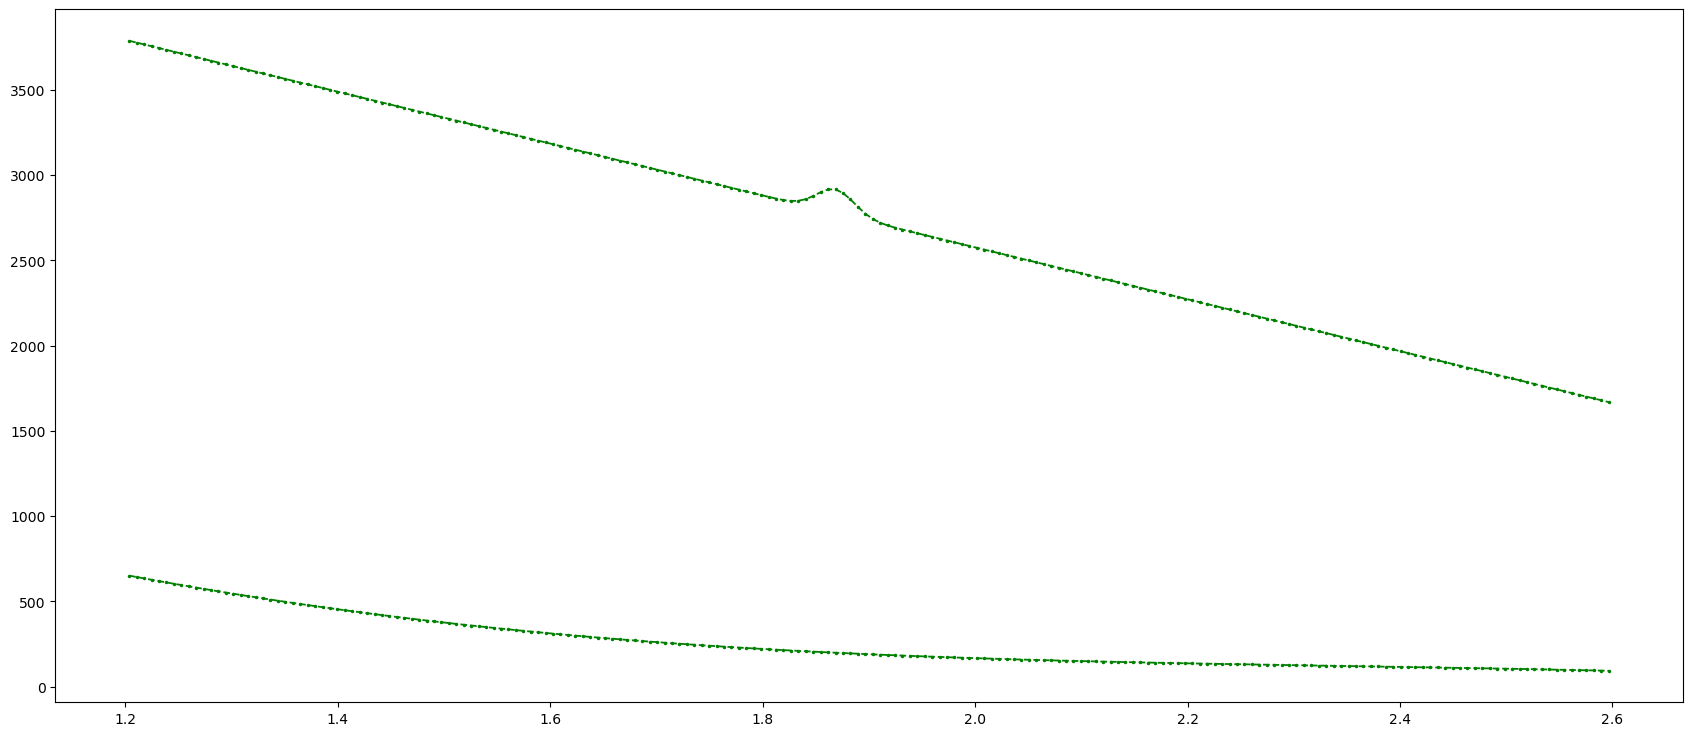

In [50]:
fig, ax = plt.subplots(figsize=(21,9))
ax.plot( both_centers, both_params[0]*norm.pdf(x=both_centers, loc= both_params[1], scale=both_params[2] ) + \
         both_params[6]*both_centers + both_params[7] ,color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

ax.plot( both_centers, both_params[3]*norm.pdf(x=both_centers, loc= both_params[4], scale=both_params[5] ) + \
         both_params[6]*both_centers + both_params[7] ,color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

plt.show()